
# QUESTION 1

{accuracy: 10}
{reasoning: 2}

Train and tune a Random Forest Classifier and an SVM Classifier with an RBF kernel using a classification dataset of your choice. Perform hyperparameter tuning for both models and compare their performance (accuracy, confusion matrix, classification report) and computational efficiency (training time).

## Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the dataset

Use the load_wine dataset from sklearn.datasets.
Specify X and y (features and the target variable)

In [2]:
data = load_wine()
X = data.data
y = data.target

## Perform Train-Test Split

Use "train_test_split" function for dataset  division

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (142, 13)
X_test shape: (36, 13)
y_train shape: (142,)
y_test shape: (36,)


## Initialize the Random Forest Classifier model and the SVM model

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

## Set up the parameters for tuning

Use n_estimators, max_depth, and min_samples_split for the parameters of random forest classifier.

Use C and gamma for the parameters of SVM model.

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_split=2, 
    random_state=42
)

svm_model = SVC(
    kernel='rbf', 
    C=1.0, 
    gamma='scale', 
    random_state=42
)

## Perform hyperparameter tuning for Random Forest using GridSearchCV


In [6]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1 # Use all available CPU cores
)

start_time = time.time()
rf_grid_search.fit(X_train, y_train)
end_time = time.time()

# printing out the best paramaters and timings
print("--- Random Forest Hyperparameter Tuning Results ---")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {rf_grid_search.best_score_:.4f}")
print(f"Total Tuning Time: {end_time - start_time:.4f} seconds")

--- Random Forest Hyperparameter Tuning Results ---
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.9786
Total Tuning Time: 4.3506 seconds


## Perform hyperparameter tuning for SVM with RBF kernel using GridSearchCV

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [11]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001, 'scale']
}

svm_grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
svm_grid_search.fit(X_train, y_train)
end_time = time.time()

# printing out the best paramaters and timings
print("--- SVM (RBF Kernel) Hyperparameter Tuning Results ---")
print(f"Best Parameters: {svm_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {svm_grid_search.best_score_:.4f}")
print(f"Total Tuning Time: {end_time - start_time:.4f} seconds")

--- SVM (RBF Kernel) Hyperparameter Tuning Results ---
Best Parameters: {'svm__C': 1, 'svm__gamma': 0.01}
Best Cross-Validation Score: 0.9788
Total Tuning Time: 0.1074 seconds


## Display the predictions and evaluations

In [12]:
# Predictions and evaluation
rf_best_model = rf_grid_search.best_estimator_
y_pred_rf = rf_best_model.predict(X_test)

svm_best_model = svm_grid_search.best_estimator_
y_pred_svm = svm_best_model.predict(X_test)

# Print the accuracy, confusion matrix, and the classification report for random forest
print("--- RANDOM FOREST EVALUATION ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

print("-" * 30)

# Print the accuracy, confusion matrix, and the classification report for RBF kernal
print("--- SVM (RBF KERNEL) EVALUATION ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=data.target_names))

--- RANDOM FOREST EVALUATION ---
Accuracy Score: 1.0000

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

------------------------------
--- SVM (RBF KERNEL) EVALUATION ---
Accuracy Score: 1.0000

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.

## Display which model is faster

In [13]:
rf_train_time = rf_grid_search.refit_time_ 
svm_train_time = svm_grid_search.refit_time_

start_rf = time.time()
rf_best_model.predict(X_test)
rf_inference_time = time.time() - start_rf

start_svm = time.time()
svm_best_model.predict(X_test)
svm_inference_time = time.time() - start_svm

print("--- SPEED COMPARISON ---")
print(f"{'Metric':<20} | {'Random Forest':<15} | {'SVM (RBF)':<15}")
print("-" * 55)
print(f"{'Refit Time (s)':<20} | {rf_train_time:<15.6f} | {svm_train_time:<15.6f}")
print(f"{'Inference Time (s)':<20} | {rf_inference_time:<15.6f} | {svm_inference_time:<15.6f}")

faster_model = "Random Forest" if rf_inference_time < svm_inference_time else "SVM"
print(f"\nConclusion: The {faster_model} was faster during the inference phase.")

--- SPEED COMPARISON ---
Metric               | Random Forest   | SVM (RBF)      
-------------------------------------------------------
Refit Time (s)       | 0.043949        | 0.002592       
Inference Time (s)   | 0.006414        | 0.004499       

Conclusion: The SVM was faster during the inference phase.


# QUESTION 2

Implement and visualize the decision boundaries for three different SVM kernels (Linear, Polynomial, and RBF) using a synthetic 2D dataset. After that, apply a handcrafted feature expansion to transform the dataset into a higher-dimensional space and train a linear SVM on this transformed data. Visualize the decision boundary in the original 2D space, and discuss the impact of the different kernels and feature expansion on the separability of the data.

## Importing necessary libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_circles, make_moons

## Generate synthetic 2D dataset with non-linear patterns

Use the inbuilt make_moons dataset to generate the synthetic 2D dataset

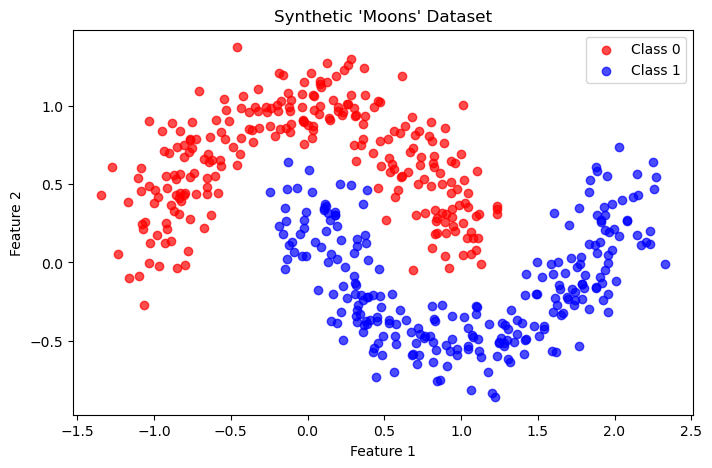

In [15]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.15, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], color='red', label='Class 0', alpha=0.7)
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], color='blue', label='Class 1', alpha=0.7)
plt.title("Synthetic 'Moons' Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Create a function to plot decision boundaries for a classifier

{accuracy: 5}

In [16]:
def plot_decision_boundaries(X, y, clf, title, feature_transform=None):
    # initialize the step size in the mesh for plotting
    h = 0.02

    # Define the grid range based on the dataset
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # This if-else block is executed when feature transformation is performed (in the last part of the question)
    if feature_transform:
        grid_points = feature_transform(np.c_[xx.ravel(), yy.ravel()])
    else:
        grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Predict class labels for each point in the grid
    Z = clf.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary as a contour plot
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot the scatter plot of the actual data points on top
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20, cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

## Train an SVM classifier with a linear kernel and plot the decision boundary for the same

{accuracy: 2}

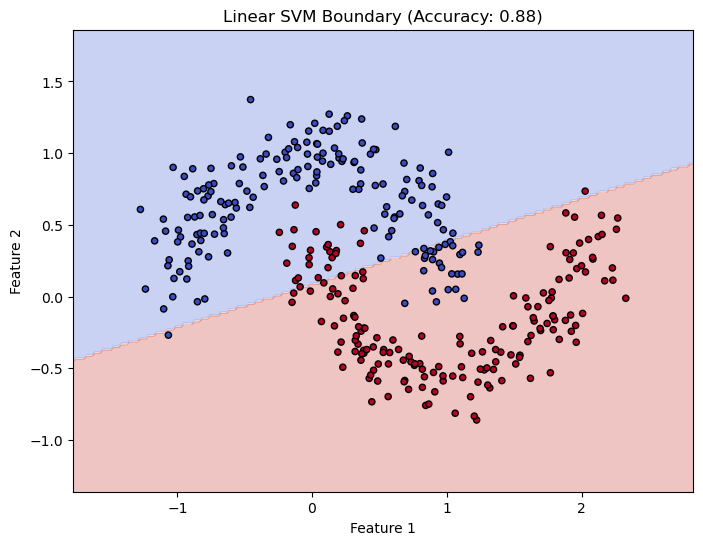

In [17]:
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_m, y_train_m)

y_pred_linear = linear_svm.predict(X_test_m)
linear_acc = accuracy_score(y_test_m, y_pred_linear)

plt.figure(figsize=(8, 6))
plot_decision_boundaries(X_train_m, y_train_m, linear_svm, f"Linear SVM Boundary (Accuracy: {linear_acc:.2f})")

## Train an SVM classifier with a polynomial kernel of degree 3 and plot the decision boundary for the same

{accuracy: 2}

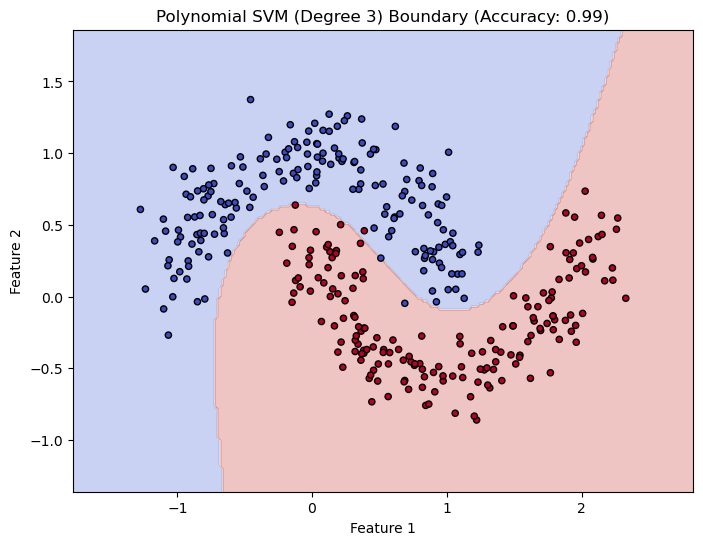

In [18]:
poly_svm = SVC(kernel='poly', degree=3, C=1.0, coef0=1, random_state=42)
poly_svm.fit(X_train_m, y_train_m)

y_pred_poly = poly_svm.predict(X_test_m)
poly_acc = accuracy_score(y_test_m, y_pred_poly)

plt.figure(figsize=(8, 6))
plot_decision_boundaries(X_train_m, y_train_m, poly_svm, f"Polynomial SVM (Degree 3) Boundary (Accuracy: {poly_acc:.2f})")

## Train an SVM classifier with an RBF (Gaussian) kernel and plot the decision boundary for the same

{accuracy 2}

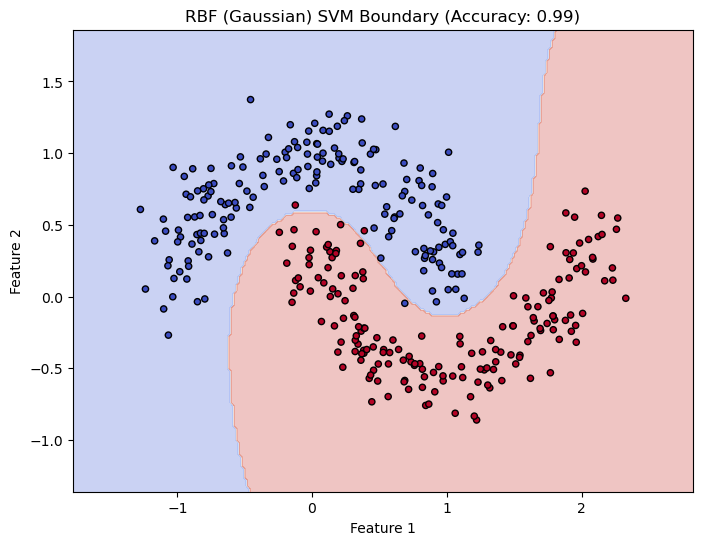

In [20]:
rbf_svm = SVC(kernel='rbf', C=1.0, gamma=1.0, random_state=42)
rbf_svm.fit(X_train_m, y_train_m)

y_pred_rbf = rbf_svm.predict(X_test_m)
rbf_acc = accuracy_score(y_test_m, y_pred_rbf)

plt.figure(figsize=(8, 6))
plot_decision_boundaries(X_train_m, y_train_m, rbf_svm, f"RBF (Gaussian) SVM Boundary (Accuracy: {rbf_acc:.2f})")

## Handcrafted Feature Expansion

{accuracy: 3}

### Use Polynomial Features to manually expand the feature space (degree 3)

In [21]:
poly_transformer = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly_transformer.fit_transform(X_train_m)
X_test_poly = poly_transformer.transform(X_test_m)

print(f"Original feature count: {X_train_m.shape[1]}")
print(f"Expanded feature count (Degree 3): {X_train_poly.shape[1]}")

Original feature count: 2
Expanded feature count (Degree 3): 9


### Now, train an SVM classifier with a linear kernel on the expanded feature set

In [24]:
poly_linear_svm = SVC(kernel='linear', C=1.0, random_state=42)

poly_linear_svm.fit(X_train_poly, y_train_m)

y_pred_poly_linear = poly_linear_svm.predict(X_test_poly)
poly_linear_acc = accuracy_score(y_test_m, y_pred_poly_linear)

plt.figure(figsize=(8, 6))
plot_decision_boundaries(
    X_train_m, 
    y_train_m, poly_linear_svm, f"Linear SVM on Manual Poly Features (Accuracy: {poly_linear_acc:.2f})", feature_transform=poly_transformer
)

TypeError: 'PolynomialFeatures' object is not callable

<Figure size 800x600 with 0 Axes>

### Plot the decision boundary in the original 2D space

In [25]:
plt.figure(figsize=(10, 7))
plot_decision_boundaries(
    X_train_m, 
    y_train_m, 
    poly_linear_svm, 
    title=f"Manual Polynomial Expansion (Degree 3) \n Linear SVM in 9D Space mapped to 2D \n Accuracy: {poly_linear_acc:.2f}",
    feature_transform=poly_transformer
)

TypeError: 'PolynomialFeatures' object is not callable

<Figure size 1000x700 with 0 Axes>

# QUESTION 3

{reasoning: 5}



Consider a dataset $\{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$ where $x_i \in \mathbb{R}^2$ and $y_i \in \{+1, -1\}$. Suppose we want to apply the kernel trick to a Support Vector Machine (SVM) to classify the data, and we choose to use the polynomial kernel of degree 2:

$$
K(x, x') = (x \cdot x' + 1)^2
$$

1. **Feature Mapping:**
   - Compute the feature mapping $\phi(x)$ corresponding to the polynomial kernel $K(x, x')$. Specifically, find the transformation $\phi: \mathbb{R}^2 \rightarrow \mathbb{R}^6$ that corresponds to this kernel function.

2. **Kernel Matrix:**
   - Given the following points $x_1 = (1, 2)$ and $x_2 = (3, 4)$, construct the kernel matrix $K$ for these two points. Show the steps involved in calculating each entry of the matrix using the given polynomial kernel.

3. **Decision Function:**
   - Suppose the SVM decision function is expressed in the feature space as $f(x) = w \cdot \phi(x) + b$, where $w$ and $b$ are learned parameters. Explain how the decision function in the original space can be derived using the kernel function.


## Solution

K=[ 
36
144
​	
  
144
676
​	
 ]


 The decision function in the original space is calculated using only the kernel function and the support vectors (x 
i
​	
  where α 
i
​	
 >0). This allows us to classify points in a high-dimensional space without ever explicitly calculating the 6-dimensional vector ϕ(x).